In [2]:
import torch
from torch import nn, Tensor
from torch.nn import Module
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, random_split

import matplotlib.pyplot as plt

In [3]:
class LinearRegression(Module):
    def __init__(self):
        super().__init__()
    
        self.linear = nn.Sequential(
            nn.Linear(1, 1)
        )

    def forward(self, x: Tensor):
        return self.linear(x)

In [4]:
class CustomDataset(Dataset):
    def __init__(self, N: int):
        super().__init__()

        self.X = torch.randn(N) * 6 - 3
        self.Y = 0.5 * self.X - 1 + torch.randn(N) * 0.5

    def __getitem__(self, index: int):
        return (self.X[index], self.Y[index])

    def __len__(self):
        return len(self.X)
        

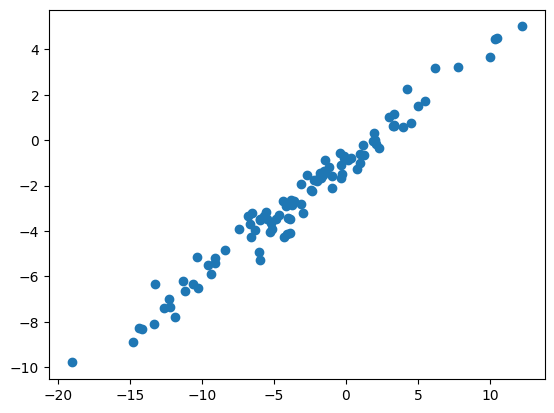

In [5]:
dataset = CustomDataset(100)

plt.scatter(dataset.X, dataset.Y)
plt.show()

In [13]:
model = LinearRegression()
loss = nn.MSELoss()
optim = Adam(model.parameters(), lr = 0.005)

In [14]:
train_data, val_data = random_split(dataset, [0.9, 0.1])

train_data = DataLoader(train_data, batch_size = 64)
val_data = DataLoader(val_data, batch_size = 64)

In [15]:
for i in range(200):
    model.train()

    ep_loss = 0

    for x,y in train_data:
        optim.zero_grad()

        output = model(x.unsqueeze(dim = -1))
        loss_ = loss(output, y.unsqueeze(dim = -1))

        loss_.backward()
        optim.step()

        ep_loss += loss_.item()
    
    
    print(f"Epoch: {i} Loss:{ep_loss / len(train_data)}")

Epoch: 0 Loss:9.3966383934021
Epoch: 1 Loss:8.956501960754395
Epoch: 2 Loss:8.528347969055176
Epoch: 3 Loss:8.11243486404419
Epoch: 4 Loss:7.709068298339844
Epoch: 5 Loss:7.318521499633789
Epoch: 6 Loss:6.9410247802734375
Epoch: 7 Loss:6.576756715774536
Epoch: 8 Loss:6.2258522510528564
Epoch: 9 Loss:5.888395547866821
Epoch: 10 Loss:5.564420461654663
Epoch: 11 Loss:5.253913164138794
Epoch: 12 Loss:4.9568140506744385
Epoch: 13 Loss:4.673016786575317
Epoch: 14 Loss:4.4023754596710205
Epoch: 15 Loss:4.144702434539795
Epoch: 16 Loss:3.8997769355773926
Epoch: 17 Loss:3.667343497276306
Epoch: 18 Loss:3.4471187591552734
Epoch: 19 Loss:3.2387930154800415
Epoch: 20 Loss:3.0420358180999756
Epoch: 21 Loss:2.8564951419830322
Epoch: 22 Loss:2.6818050146102905
Epoch: 23 Loss:2.517586588859558
Epoch: 24 Loss:2.3634508848190308
Epoch: 25 Loss:2.219001889228821
Epoch: 26 Loss:2.0838383436203003
Epoch: 27 Loss:1.9575556516647339
Epoch: 28 Loss:1.839750587940216
Epoch: 29 Loss:1.7300193905830383
Epoch: 30

In [16]:
model.eval()

x_test = []
outputs = []

with torch.no_grad():
    errors = []

    for x,y in val_data:
        output = model(x.unsqueeze(dim = -1))

        x_test.append(x)
        outputs.append(output)

        loss_ = loss(y.unsqueeze(dim = -1), output)

        errors.append(loss_)

print(errors)

[tensor(0.3548)]


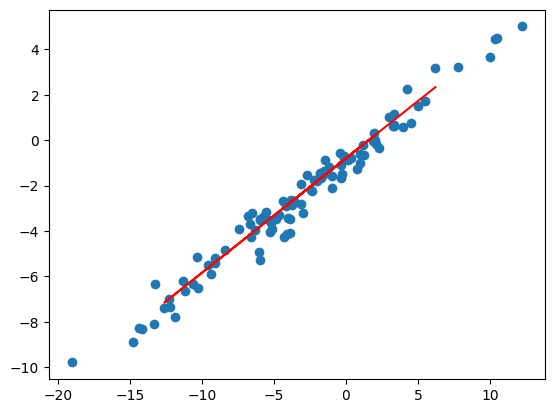

In [17]:
plt.scatter(dataset.X, dataset.Y)
plt.plot(x_test[0].detach().numpy(), outputs[0], color = "r")
plt.show()

In [107]:
model.state_dict()

OrderedDict([('linear.0.weight', tensor([[0.4729]])),
             ('linear.0.bias', tensor([-0.6181]))])